In [47]:
import pandas as pd

df = pd.read_csv("table2_upcoming_flights.csv")

In [48]:
df = df[df["destination"] == "JFK"]

In [49]:
df = df[df["fare_class"] == "Economy"]

In [50]:
df.head()

,flight_id,date,origin,destination,distance,flight_time,route_popularity,aircraft,seat_capacity,departure_hour,...,special_event,weather_score,fuel_price,economic_index,booking_stage,fare_class,fare_capacity,price,competitor_price,price_ratio
0,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Early,Economy,165,225.36,225.54,1.013
1,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Middle,Economy,165,263.58,264.13,1.011
2,DFW_JFK,2023-01-10,DFW,JFK,1391,3.5,1.2,A321neo,220,10,...,0,1.0,100,100,Final,Economy,165,323.64,320.62,1.022


In [51]:
df = df.drop(
    columns=[
        
        'flight_id',
        'origin', #same for all
        'fare_class', #same for all
        'date'
        
    ]
)

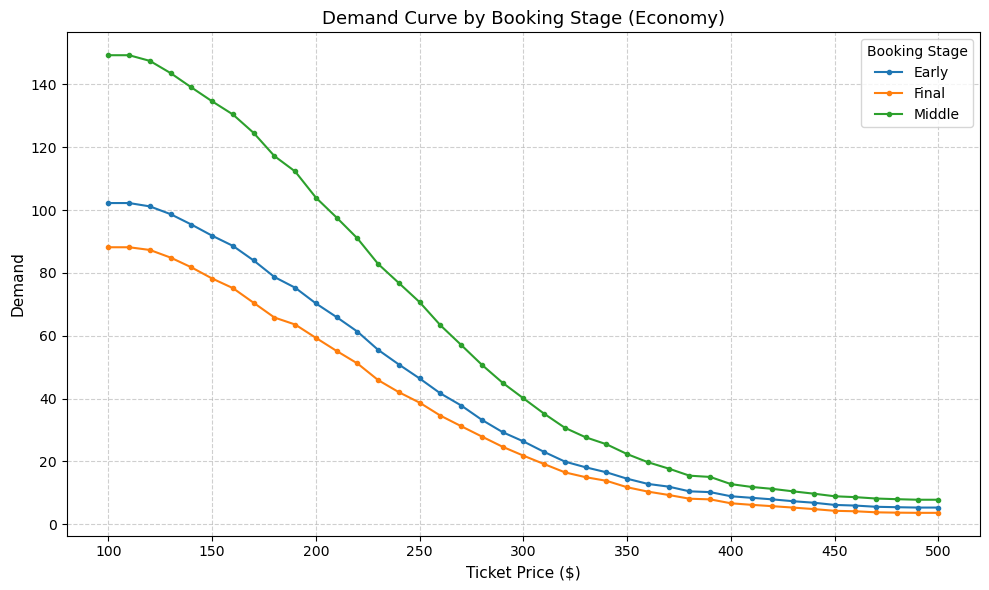

In [54]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load saved artifacts
preprocessor = joblib.load("preprocessor_pipeline_demand_economy.joblib")
model = joblib.load("demand_forecasting_economy_model.joblib")

# 2. Define price range
prices = np.arange(100, 510, 10)  # $100, $130, ...

# 3. Generate predictions across the price spectrum
results = []

# Iterate directly through 'df' since each row already represents a unique booking stage
for _, flight in df.iterrows():
    stage = flight["booking_stage"]

    # Replicate the single flight row for each price point
    scenario_df = pd.DataFrame([flight] * len(prices))

    # Overwrite the price feature with the scenario prices
    scenario_df["price"] = prices

    # Preprocess features and predict demand
    X_transformed = preprocessor.transform(scenario_df)
    demand = model.predict(X_transformed)

    # Store scenario results
    stage_results = pd.DataFrame(
        {
            "booking_stage": stage,
            "price": prices,
            "demand": demand,  
        }
    )
    results.append(stage_results)

# Combine all predictions into a single DataFrame
demand_df = pd.concat(results, ignore_index=True)

# 4. Plot Demand Curves
plt.figure(figsize=(10, 6))
for stage, group in demand_df.groupby("booking_stage"):
    plt.plot(
        group["price"],
        group["demand"],
        label=stage,
        marker="o",
        markersize=3,
    )

plt.title("Demand Curve by Booking Stage (Economy)", fontsize=13)
plt.xlabel("Ticket Price ($)", fontsize=11)
plt.ylabel("Demand", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Booking Stage")
plt.tight_layout()
plt.show()

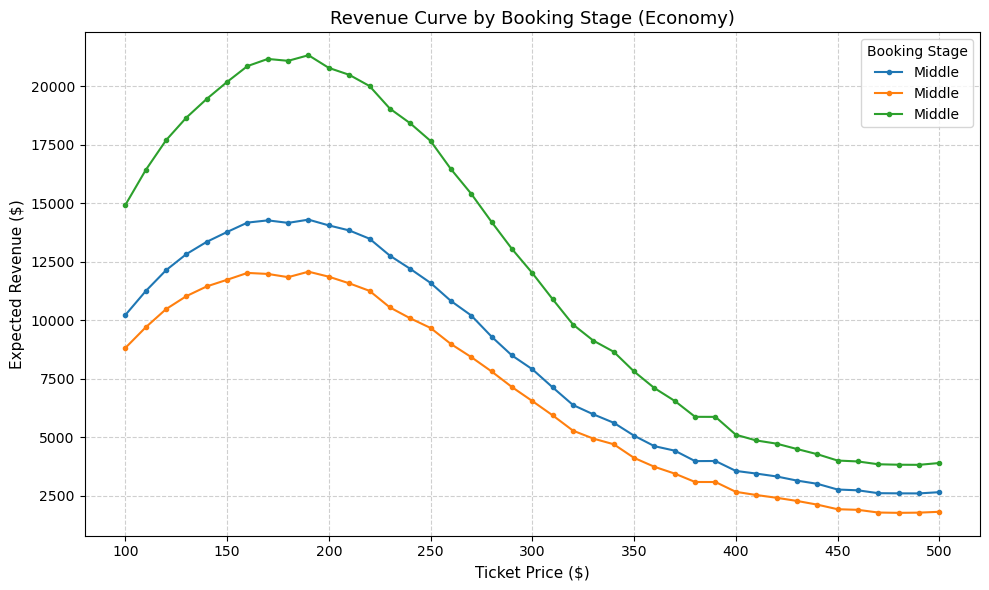

--- Revenue-Maximizing Price Points ---
booking_stage  price  expected_revenue
        Early    190      14305.255491
        Final    190      12079.173303
       Middle    190      21338.020665


In [55]:
# 1. Compute expected revenue
demand_df["expected_revenue"] = (
    demand_df["price"] * demand_df["demand"]
)

# 2. Plot Revenue Curves
plt.figure(figsize=(10, 6))
for dest, group in demand_df.groupby("booking_stage"):
    plt.plot(
        group["price"],
        group["expected_revenue"],
        label=stage,
        marker="o",
        markersize=3,
    )

plt.title("Revenue Curve by Booking Stage (Economy)", fontsize=13)
plt.xlabel("Ticket Price ($)", fontsize=11)
plt.ylabel("Expected Revenue ($)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Booking Stage")
plt.tight_layout()
plt.show()

# 3. Print the optimal revenue-maximizing price for each booking stage
optimal_prices = demand_df.loc[
    demand_df.groupby("booking_stage")["expected_revenue"].idxmax()
]

print("--- Revenue-Maximizing Price Points ---")
print(
    optimal_prices[["booking_stage", "price", "expected_revenue"]].to_string(
        index=False
    )
)

In [56]:
import numpy as np
import pandas as pd

# Ensure demand_df is sorted by Booking Stage and price
demand_df = demand_df.sort_values(by=["booking_stage", "price"]).copy()

# List to store elasticity values
elasticity_results = []

# Group by booking stage to calculate step-by-step elasticity
for stage, group in demand_df.groupby("booking_stage"):
    group = group.reset_index(drop=True)

    # Shift values to calculate delta (dq and dp)
    p1 = group["price"].iloc[:-1].values
    p2 = group["price"].iloc[1:].values

    q1 = group["demand"].iloc[:-1].values
    q2 = group["demand"].iloc[1:].values

    dp = p2 - p1
    dq = q2 - q1

    # Avoid division by zero if initial demand is 0
    valid_mask = q1 != 0
    dq, dp, p1, q1 = (
        dq[valid_mask],
        dp[valid_mask],
        p1[valid_mask],
        q1[valid_mask],
    )

    # Point elasticity formula: (dq / dp) * (p1 / q1)
    elasticities = (dq / dp) * (p1 / q1)

    # Average elasticity for this route
    avg_elasticity = np.mean(elasticities)

    elasticity_results.append(
        {"booking_stage": stage, "avg_elasticity": avg_elasticity}
    )

# Create summary DataFrame for route elasticity
elasticity_df = pd.DataFrame(elasticity_results)
print(elasticity_df)

  booking_stage  avg_elasticity
0         Early       -2.145824
1         Final       -2.334060
2        Middle       -2.150876


In [57]:
# 1. Select and rename required columns from demand_df
full_price_table = demand_df[
    ["booking_stage", "price", "demand", "expected_revenue"]
].copy()

# 2. Rename columns to match requested headers
full_price_table = full_price_table.rename(
    columns={
        "booking_stage": "Booking Stage",
        "price": "Price",
        "demand": "Demand",
        "expected_revenue": "Expected Revenue",
    }
)

# 3. Sort cleanly by Booking Stage and Price
full_price_table = full_price_table.sort_values(
    by=["Booking Stage", "Price"]
).reset_index(drop=True)

# 4. Save the full table to CSV (with unformatted numbers for data precision)
full_price_table.to_csv(
    "Expected_Revenue_Economy_JFK.csv", index=False
)
print(
    "Table successfully saved to 'Expected_Revenue_Economy_JFK.csv'"
)

# 5. Format numbers for clean display
formatted_table = full_price_table.copy()
formatted_table["Price"] = formatted_table["Price"].apply(
    lambda x: f"${x:,.0f}"
)
formatted_table["Demand"] = formatted_table["Demand"].round(1)
formatted_table["Expected Revenue"] = formatted_table["Expected Revenue"].apply(
    lambda x: f"${x:,.2f}"
)

# 6. Display only the first 15 rows
print("\n--- First 25 Rows ---")
print(formatted_table.head(25).to_string(index=False))

Table successfully saved to 'Expected_Revenue_Economy_JFK.csv'

--- First 25 Rows ---
Booking Stage Price  Demand Expected Revenue
        Early  $100   102.3       $10,225.42
        Early  $110   102.3       $11,247.96
        Early  $120   101.2       $12,142.38
        Early  $130    98.7       $12,831.83
        Early  $140    95.4       $13,356.88
        Early  $150    91.8       $13,777.35
        Early  $160    88.6       $14,179.00
        Early  $170    84.0       $14,274.30
        Early  $180    78.7       $14,166.99
        Early  $190    75.3       $14,305.26
        Early  $200    70.3       $14,058.53
        Early  $210    65.9       $13,844.41
        Early  $220    61.3       $13,490.16
        Early  $230    55.5       $12,764.54
        Early  $240    50.8       $12,201.40
        Early  $250    46.4       $11,598.28
        Early  $260    41.6       $10,826.86
        Early  $270    37.8       $10,204.79
        Early  $280    33.2        $9,298.91
        Early 